**NAMA: DIVA ANGGRAENI**

**NPM: 24083010065**

**MATEMATIKA DISKRIT (A)**

**TUGAS PENGGANTI UTS**

# **1. Cari satu artikel ilmiah bebas dengan syarat:**
- DOI valid
- berbahasa Inggris atau Indonesia
Cuplik bagian abstrak, pendahuluan (introduction), dan kesimpulan (conclusion). Tuliskan asal negara corresponding author.


**Judul Artikel:** Pengaruh Olahraga Terhadap Mood dan Tingkat Stress Individu

**Penulis:** Ayuna Davatiansyah, dkk.

**Afiliasi:** Universitas Muria Kudus

**Asal Negara *Corresponding Author*:** Indonesia

**Jurnal:** Jurnal Psikologi Islam, Vol. 8 No. 2, 2025

**DOI:** https://doi.org/10.46781/nathiqiyyah.v8i2

In [112]:
!pip install pdfplumber

In [113]:
import pdfplumber
import re

teks = ""
with pdfplumber.open("artikel_uts.pdf") as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()

        if not page_text:
            continue

        lines = page_text.split("\n")
        if len(lines) > 2:
            lines = lines[1:-1] #supaya header dan footer tidak ikut terbaca
        teks += "\n".join(lines) + "\n"

#cuplik bagian abstrak, pendahuluan, dan kesimpulan
cuplik_abstrak = re.search(r"Abstrak(.*?)(Kata Kunci|$)", teks, flags=re.S|re.I)
cuplik_pendahuluan = re.search(r"A. Pendahuluan(.*?)(B. Metode Penelitian|$)", teks, flags=re.S|re.I)
cuplik_kesimpulan = re.search(r"D. Kesimpulan(.*?)(Daftar Pustaka|$)", teks, flags=re.S|re.I)

abstrak = cuplik_abstrak.group(1).strip() if cuplik_abstrak else ""
pendahuluan = cuplik_pendahuluan.group(1).strip() if cuplik_pendahuluan else ""
kesimpulan = cuplik_kesimpulan.group(1).strip() if cuplik_kesimpulan else ""

print("- ABSTRAK -\n", abstrak, "\n")
print("- PENDAHULUAN -\n", pendahuluan, "\n")
print("- KESIMPULAN -\n", kesimpulan)

- ABSTRAK -
 Penelitian ini bertujuan untuk menganalisis pengaruh olahraga terhadap mood dan tingkat stres individu,
khususnya pada mahasiswa. Metode penelitian yang digunakan adalah kuantitatif dengan desain one
group pretest-posttest, melibatkan tujuh partisipan yang dipilih melalui teknik purposive sampling
berdasarkan kriteria tertentu. Intervensi berupa olahraga ringan selama lima menit dilakukan secara rutin
selama tujuh hari berturut-turut. Pengukuran dilakukan menggunakan instrumen skala afeksi positif dan
negatif sebelum dan sesudah intervensi, serta refleksi harian untuk menggali pengalaman subjektif
partisipan. Hasil penelitian menunjukkan bahwa intervensi olahraga singkat dapat meningkatkan emosi
positif dan menurunkan emosi negatif pada sebagian partisipan, terutama mereka yang memiliki motivasi
intrinsik dan persepsi positif terhadap olahraga. Namun, tidak semua partisipan mengalami perubahan
signifikan, yang menunjukkan bahwa efektivitas intervensi dipengaruhi oleh fakto

**Penjelasan:**

Ini adalah langkah awal untuk mengambil hanya isi dari abstrak, pendahuluan, dan kesimpulan. Output di atas membuktikan bahwa bagian-bagian yang diinginkan berhasil dicuplik secara utuh dan mampu mengabaikan tulisan pada bagian header dan footer. Dengan begitu, dapat dilakukan identifikasi lanjut mengenai kata, kalimat, hingga paragraf pada bagian yang sudah dicuplik.

# **2. Tabel pivot konsonan dan vokal dalam kata**
Tabulasi kata-kata berdasarkan berapa jumlah konsonan atau vokal di dalamnya: sumbu x (konsonan), sumbu y (vokal).
Buat dua heatmap/tabel yang berisi:
- berapa frekuensi dari tiap kombinasi konsonan-vokal yang ditemukan
- berapa cacah kata yang masuk dalam tiap kombinasi konsonan-vokal

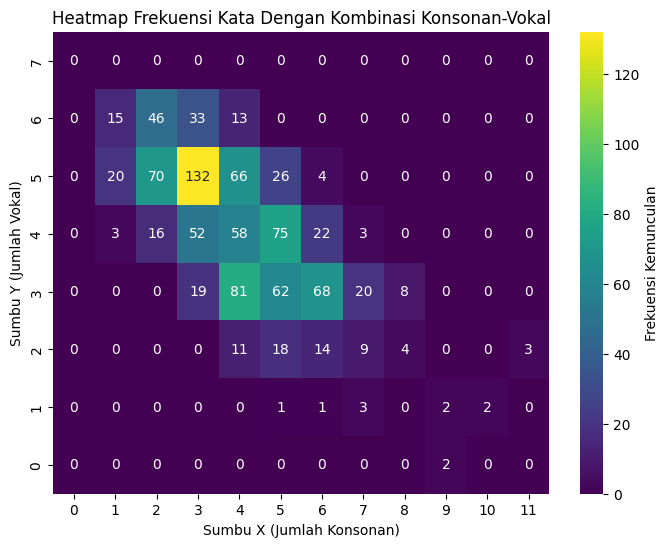

In [114]:
## HEATMAP FREKUENSI DARI TIAP KOMBINASI KONSONAN-VOKAL
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re

gabungan = " ".join([abstrak + pendahuluan + kesimpulan])
kata = re.findall(r"[A-Za-z]+", gabungan.lower())

vokal = set("aiueo")
def hitung_cv(kata):
    v = sum(1 for h in kata if h in vokal)
    c = sum(1 for h in kata if h.isalpha() and h not in vokal)
    return c, v

freq = Counter()
for k in kata:
    c, v = hitung_cv(k)
    freq[(c, v)] += 1
max_c = max(c for (c, v) in freq)
max_v = max(v for (c, v) in freq)

tabulasi = np.zeros((max_v + 1, max_c + 1), dtype=int)
for (c, v), n in freq.items():
    tabulasi[v, c] = n

plt.figure(figsize=(8,6))
sns.heatmap(tabulasi[::-1], annot=True, fmt=".0f", cmap="viridis",
            cbar_kws={"label": "Frekuensi Kemunculan"})
plt.title("Heatmap Frekuensi Kata Dengan Kombinasi Konsonan-Vokal")
plt.xlabel("Sumbu X (Jumlah Konsonan)")
plt.ylabel("Sumbu Y (Jumlah Vokal)")
plt.gca().invert_yaxis()
plt.show()

**Penjelasan Heatmap Frekuensi Kata Dengan Kombinasi Konsonan-Vokal:**

Heatmap di atas menggambarkan frekuensi kemunculan kombinasi jumlah konsonan dan vokal dalam kata. Semakin terang warnanya, maka semakin sering jumlah kombinasi tersebut muncul. Seperti pada kombinasi 3 konsonan dengan 5 vokal memiliki warna sangat terang dengan frekuensi sebesar 132 yang berarti kombinasi tersebut paling sering muncul. Sedangkan kombinasi dengan konsonan atau vokal yang terlalu sedikit atau terlalu banyak jarang ditemukan, hal tersebut terlihat pada area berwarna gelap di tepi. Dengan begitu dapat dikatakan bahwa kata umumnya memiliki keseimbangan antara konsonan dan vokal.

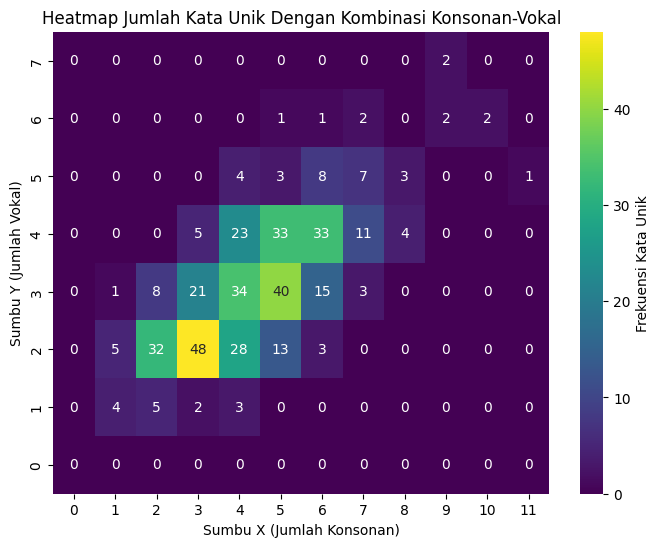

In [115]:
## HEATMAP CACAH KATA YANG MASUK DALAM TIAP KOMBINASI KONSONAN-VOKAL
unik = set(kata)
freq_unik = Counter()

for k in unik:
  c, v = hitung_cv(k)
  freq_unik[(c, v)] += 1

max_c = max(c for (c, v) in freq_unik)
max_v = max(v for (c, v) in freq_unik)

tabulasi_unik = np.zeros((max_v + 1, max_c + 1), dtype=int)
for (c, v), n in freq_unik.items():
  tabulasi_unik[v, c] = n

plt.figure(figsize=(8,6))
sns.heatmap(tabulasi_unik, annot=True, fmt=".0f", cmap="viridis",
            cbar_kws={"label": "Frekuensi Kata Unik"})
plt.title("Heatmap Jumlah Kata Unik Dengan Kombinasi Konsonan-Vokal")
plt.xlabel("Sumbu X (Jumlah Konsonan)")
plt.ylabel("Sumbu Y (Jumlah Vokal)")
plt.gca().invert_yaxis()
plt.show()

**Penjelasan Heatmap Cacah Kata Yang Masuk Dalam Tiap Kombinasi Konsonan-Vokal:**

Heatmap di atas menggambarkan jumlah kata unik berdasarkan kombinasi jumlah konsonan dan vokal. Semakin terang warnanya, menunjukkan lebih banyak kata unik pada kombinasi tersebut. Seperti yang terlihat pada kombinasi 3 konsonan dengan 2 vokal memiliki frekuensi tertinggi yang juga ditandai dengan warnanya paling terang dibandingkan yang lain, hal tersebut menandakan bahwa sebagian besar kata unik berada pada kisaran kombinasi tersebut.

# **3. Jumlah kata dalam kalimat**
Identifikasi berapa jumlah kata dalam tiap kalimat, kemudian buat histogramnya

In [116]:
## MENGIDENTIFIKASI JUMLAH KATA DALAM TIAP KALIMAT
import pandas as pd
kalimat = re.split(r'[.!?]+', gabungan)
kalimat = [k.strip() for k in kalimat if k.strip()]  #buang kalimat kosong

jumlah_kata = [len(re.findall(r"[A-Za-z]+", k)) for k in kalimat]

data_kalimat = pd.DataFrame({
    "Kalimat ke": range(1, len(kalimat)+1),
    "Kalimat": kalimat,
    "Jumlah Kata": jumlah_kata
})

print("- Jumlah Kata per Kalimat -")
data_kalimat

- Jumlah Kata per Kalimat -


,Kalimat ke,Kalimat,Jumlah Kata
0,1,"Penelitian ini bertujuan untuk menganalisis pengaruh olahraga terhadap mood dan tingkat stres individu,\nkhususnya pada mahasiswa",16
1,2,"Metode penelitian yang digunakan adalah kuantitatif dengan desain one\ngroup pretest-posttest, melibatkan tujuh partisipan yang dipilih melalui teknik purposive sampling\nberdasarkan kriteria tertentu",24
2,3,Intervensi berupa olahraga ringan selama lima menit dilakukan secara rutin\nselama tujuh hari berturut-turut,15
3,4,"Pengukuran dilakukan menggunakan instrumen skala afeksi positif dan\nnegatif sebelum dan sesudah intervensi, serta refleksi harian untuk menggali pengalaman subjektif\npartisipan",21
4,5,"Hasil penelitian menunjukkan bahwa intervensi olahraga singkat dapat meningkatkan emosi\npositif dan menurunkan emosi negatif pada sebagian partisipan, terutama mereka yang memiliki motivasi\nintrinsik dan persepsi positif terhadap olahraga",29
5,6,"Namun, tidak semua partisipan mengalami perubahan\nsignifikan, yang menunjukkan bahwa efektivitas intervensi dipengaruhi oleh faktor motivasi, kebiasaan\nawal, dan kondisi psikologis eksternal",22
6,7,"Penelitian ini merekomendasikan olahraga sebagai intervensi\npraktis untuk meningkatkan kesejahteraan emosional, dengan mempertimbangkan kesiapan mental dan\nmakna personal bagi individu",20
7,8,Temuan ini berkontribusi pada pemahaman ilmiah mengenai pentingnya\npendekatan personal dalam penerapan olahraga untuk kesehatan mental,16
8,9,"Dalam kehidupan modern yang serba cepat dan kompetitif, tekanan mental dan\nemosional menjadi bagian yang tidak bisa dihindari dari keseharian",20
9,10,"Stres didefinisikan\nsebagai respons psikologis dan fisiologis terhadap tuntutan yang melebihi kemampuan\nindividu untuk menghadapinya (Lazarus & Folkman, 1984)",17


**Penjelasan Identifikasi Jumlah Kata Dalam Tiap Kalimat:**

Tabel tersebut untuk menampilkan bagaimana sistem dapat mendefinisikan sebuah kalimat dengan memisahkan teks berdasarkan tanda titik (.), tanda seru (!), dan tanda tanda tanya (?). Sebuah kata didefinisikan sebagai rangkaian huruf (A-Z atau a-z), sehingga setiap huruf tanpa spasi atau tanda baca dianggap satu kata. Hasil akhirnya seperti tabel di atas yang menampilkan urutan kalimat (mulai abstrak), isi kalimat, dan jumlah kata. Namun, mungkin beberapa hasil yang ditampilkan tidak begitu mendefinisikan sebuah kalimat secara persis. Seperti pada kalimat ke-21 yang berisi ", 1994; Ratey, 2008)" seharusnya masih menjadi bagian dari kalimat ke-20, namun karena kalimat ke-20 berisi ((Thayer et al., 1994; Ratey, 2008)) yang dimana terdapat tanda titik (.), sehingga sistem secara otomatis akan memisahkan teks tersebut. Secara keseluruhan sistem sudah mampu memilih kata yang hanya terdiri dari huruf.

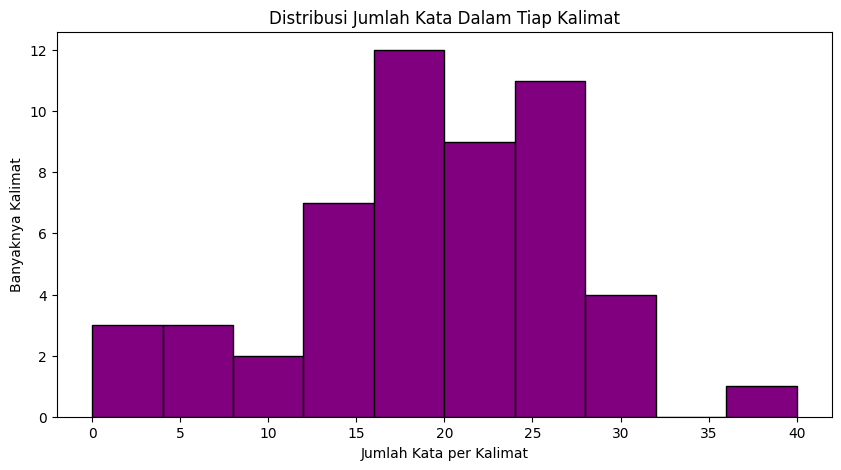

In [117]:
## HISTOGRAM DISTRIBUSI JUMLAH KATA DALAM TIAP KALIMAT
plt.figure(figsize=(10,5))
plt.hist(data_kalimat["Jumlah Kata"], bins=10, color='purple', edgecolor='black')
plt.title("Distribusi Jumlah Kata Dalam Tiap Kalimat")
plt.xlabel ("Jumlah Kata per Kalimat")
plt.ylabel("Banyaknya Kalimat")
plt.show()

**Penjelasan Histogram Jumlah Kata Dalam Tiap Kalimat:**

Histogram tersebut menggambarkan distribusi jumlah kata dalam tiap kalimat. Sumbu X menunjukkan jumlah kata per kalimat, sedangkan sumbu Y menunjukkan banyaknya kalimat dengan jumlah kata tersebut. Dari grafik terlihat bahwa sebagian besar kalimat memiliki kisaran 15-20 kata, yang berarti panjang kalimat dalam teks tergolong sedang. Sementara itu, hanya sedikit kalimat yang sangat pendek atau sangat panjang.

# **4. Jumlah kalimat dalam paragraf**
Identifikasi berapa jumlah kalimat dalam tiap paragraf, kemudian buat histogramnya

In [118]:
## MENGIDENTIFIKASI JUMLAH KALIMAT DALAM TIAP PARAGRAF
def pisah_paragraf_pdf(bagian):
  bagian = re.sub(r'\r', '', bagian)
  bagian = re.sub(r' +', ' ', bagian)
  bagian = re.sub(r'(?<=[a-z0-9,;:])\n(?=[a-z0-9])', ' ', bagian)
  paragraf = re.split(r'(?<=[.!?])\s*\n(?=[A-Z])', bagian)
  paragraf = [p.strip() for p in paragraf if len(p.strip()) > 0]
  return paragraf

paragraf_abstrak = pisah_paragraf_pdf(abstrak)
paragraf_pendahuluan = pisah_paragraf_pdf(pendahuluan)
paragraf_kesimpulan = pisah_paragraf_pdf(kesimpulan)

semua_paragraf = []
for label, kumpulan in [
    ("Abstrak", paragraf_abstrak),
    ("Pendahuluan", paragraf_pendahuluan),
    ("Kesimpulan", paragraf_kesimpulan)
]:
    for i, p in enumerate(kumpulan, start=1):
        kalimat = re.findall(r'[^.!?]+[.!?](?=\s|$)', p)
        semua_paragraf.append({
            "Bagian": label,
            "Paragraf ke": i,
            "Paragraf": p,
            "Jumlah Kalimat": len(kalimat)
        })
data_paragraf = pd.DataFrame(semua_paragraf)

print("- Jumlah Kalimat per Paragraf -")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

data_paragraf

- Jumlah Kalimat per Paragraf -


,Bagian,Paragraf ke,Paragraf,Jumlah Kalimat
0,Abstrak,1,"Penelitian ini bertujuan untuk menganalisis pengaruh olahraga terhadap mood dan tingkat stres individu, khususnya pada mahasiswa. Metode penelitian yang digunakan adalah kuantitatif dengan desain one group pretest-posttest, melibatkan tujuh partisipan yang dipilih melalui teknik purposive sampling berdasarkan kriteria tertentu. Intervensi berupa olahraga ringan selama lima menit dilakukan secara rutin selama tujuh hari berturut-turut. Pengukuran dilakukan menggunakan instrumen skala afeksi positif dan negatif sebelum dan sesudah intervensi, serta refleksi harian untuk menggali pengalaman subjektif partisipan. Hasil penelitian menunjukkan bahwa intervensi olahraga singkat dapat meningkatkan emosi positif dan menurunkan emosi negatif pada sebagian partisipan, terutama mereka yang memiliki motivasi intrinsik dan persepsi positif terhadap olahraga. Namun, tidak semua partisipan mengalami perubahan signifikan, yang menunjukkan bahwa efektivitas intervensi dipengaruhi oleh faktor motivasi, kebiasaan awal, dan kondisi psikologis eksternal. Penelitian ini merekomendasikan olahraga sebagai intervensi praktis untuk meningkatkan kesejahteraan emosional, dengan mempertimbangkan kesiapan mental dan makna personal bagi individu. Temuan ini berkontribusi pada pemahaman ilmiah mengenai pentingnya pendekatan personal dalam penerapan olahraga untuk kesehatan mental.",8
1,Pendahuluan,1,"Dalam kehidupan modern yang serba cepat dan kompetitif, tekanan mental dan emosional menjadi bagian yang tidak bisa dihindari dari keseharian. Stres didefinisikan sebagai respons psikologis dan fisiologis terhadap tuntutan yang melebihi kemampuan individu untuk menghadapinya (Lazarus & Folkman, 1984). Sedangkan mood, atau suasana hati, merujuk pada keadaan emosional jangka pendek yang dapat berubah-ubah dan memengaruhi cara individu memandang dunia dan dirinya sendiri (Watson et al., 1988). Keseimbangan kedua aspek ini sangat penting dalam menunjang kesehatan mental.",4
2,Pendahuluan,2,"World Health Organization (WHO) tahun 2019 mencatat bahwa lebih dari 970 juta orang di dunia mengalami gangguan mental, dengan depresi dan kecemasan sebagai dua bentuk paling umum. Bahkan diprediksi, pada tahun 2030 depresi akan menjadi penyebab utama beban penyakit global. Di Indonesia, data Riskesdas (2018)\nmenunjukkan bahwa 9,8% penduduk mengalami gangguan mental emosional, dan angka tersebut cenderung meningkat pasca pandemi COVID-19.",3
3,Pendahuluan,3,"Dalam upaya menekan dampak tersebut, pendekatan non-farmakologis seperti olahraga menjadi alternatif yang semakin dilirik. Olahraga secara fisiologis merangsang pelepasan endorfin dan dopamin dua hormon yang berperan dalam menghasilkan perasaan senang dan tenang. Di saat yang sama, aktivitas fisik membantu menurunkan kadar kortisol, hormon stres utama dalam tubuh. Dengan mekanisme tersebut, olahraga diyakini berperan sebagai penyeimbang sistem saraf dan hormonal yang berkontribusi langsung pada kesehatan mental, termasuk kestabilan mood dan penurunan stres\n(Thayer et al., 1994; Ratey, 2008).",4
4,Pendahuluan,4,"Penelitian oleh Craft & Perna (2004) menegaskan bahwa olahraga dapat menjadi strategi coping efektif, terutama dalam menghadapi kecemasan dan depresi. Mereka menyatakan bahwa olahraga membantu regulasi emosi melalui peningkatan neurotransmitter seperti serotonin dan norepinefrin, yang terbukti berperan dalam stabilitas afektif. Demikian pula, Reed & Ones (2006) menemukan bahwa aktivitas fisik meskipun singkat, dapat meningkatkan mood secara langsung setelah sesi olahraga.",3
5,Pendahuluan,5,"Penelitian oleh Saufi et al. (2024) menegaskan bahwa olahraga memiliki dampak positif terhadap berbagai aspek kesehatan mental. Mereka menemukan bahwa partisipasi dalam aktivitas fisik dapat menurunkan tingkat kecemasan, meningkatkan suasana hati, serta memperbaiki kualitas tidur. Selain itu, faktor-faktor seperti intensitas, durasi, dan jenis olahraga memengaruhi seberapa b

**Penjelasan Identifikasi Jumlah Kalimat Dalam Tiap Paragraf:**

Tabel tersebut menampilkan bahwa sistem terbukti mampu memisahkan paragraf satu dengan yang lain. Pada baris "paragraf = re.split(r'(?<=[.!?])\s*\n(?=[A-Z])', bagian)" mendefinisikan jika terdapat tanda titik/seru/tanya, lalu enter (baris baru), lalu huruf kapital, maka dianggap sebagai paragraf baru. Dengan aturan tersebut, pada pendahuluan paragraf ke-8 dan kesimpulan paragraf ke-4 dianggap sebagai paragraf baru meskipun pada file masih menjadi bagian dari paragraf sebelumnya. Secara keseluruhan, program sudah mampu memberikan output sesuai instruksi untuk dilakukan analisis lanjut berupa histogram. Meskipun masih ada 2 bagian yang mengganjal, namun program sudah bekerja hampir sempurna.

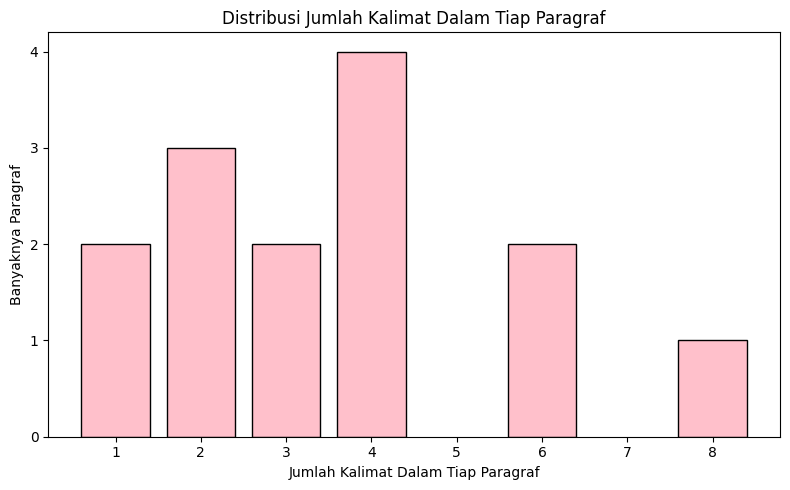

In [119]:
## HISTOGRAM DISTRIBUSI JUMLAH KALIMAT DALAM TIAP PARAGRAF
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    data_paragraf["Jumlah Kalimat"].value_counts().sort_index().index,
    data_paragraf["Jumlah Kalimat"].value_counts().sort_index().values,
    color='pink', edgecolor='black', align='center'
)

plt.gca().yaxis.get_major_locator().set_params(integer=True)
plt.xlabel("Jumlah Kalimat Dalam Tiap Paragraf")
plt.ylabel("Banyaknya Paragraf")
plt.title("Distribusi Jumlah Kalimat Dalam Tiap Paragraf")
plt.tight_layout()
plt.show()

**Penjelasan Histogram Distribusi Jumlah Kalimat Dalam Tiap Paragraf:**

Histrogram tersebut menunjukkan penyebaran jumlah kalimat dalam tiap paragraf. Dalam grafik terlihat bahwa paragraf paling banyak terdiri dari empat kalimat, yang berarti sebagian besar paragraf punya panjang yang sedang. Hanya satu paragraf yang memiliki jumlah kalimat paling banyak.

# **Analisis Tambahan**
Dari beberapa analisis yang telah dilakukan, saya ingin melakukan analisis tambahan untuk mengetahui rata-rata jumlah kalimat pada tiap bagian (abstrak, pendahuluan, dan kesimpulan). Tujuan analisis tersebut untuk mengetahui kepadatan informasi dari setiap bagian dan mengetahui apakah pola penulisan seperti pada umumnya karya ilmuiah yang di mana bagian pendahuluan lebih banyak dibandingkan abstrak dan kesimpulan.

/tmp/ipython-input-1499282290.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: round(x["Jumlah Kata"].sum() / x["Jumlah Kalimat"].sum()))


        Bagian  Rata-rata Jumlah Kata per Kalimat
0      Abstrak                                 20
1  Pendahuluan                                 19
2   Kesimpulan                                 23


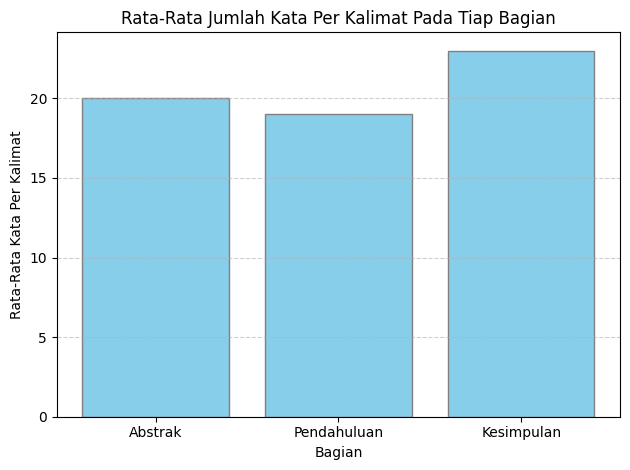

In [128]:
## MEAN JUMLAH KATA PER KALIMAT PADA TIAP BAGIAN
data_paragraf["Jumlah Kata"] = data_paragraf["Paragraf"].apply(lambda x: len(x.split()))

mean_kata = (
    data_paragraf.groupby("Bagian")
    .apply(lambda x: round(x["Jumlah Kata"].sum() / x["Jumlah Kalimat"].sum()))
    .reindex(["Abstrak", "Pendahuluan", "Kesimpulan"])
    .reset_index(name="Rata-rata Jumlah Kata per Kalimat")
)

print(mean_kata)

plt.bar(mean_kata["Bagian"], mean_kata["Rata-rata Jumlah Kata per Kalimat"],
        color="skyblue", edgecolor="grey")
plt.title("Rata-Rata Jumlah Kata Per Kalimat Pada Tiap Bagian")
plt.xlabel("Bagian")
plt.ylabel("Rata-Rata Kata Per Kalimat")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Penjelasan Rata-Rata Jumlah Kata Per Kalimat Pada Tiap Bagian:**

Berdasarkan hasil visualisasi tersbut, rata-rata jumlah kata pada kesimpulan lebih tinggi dibandingkan abstrak dan pendahuluan. Bagian pendahuluan memang terlihat lebih banyak isinya dibandingkan kesimpulan, namun ada beberapa faktor yang menyebabkan rata-rata jumlah kata dalam tiap kalimatnya lebih rendah.
1. Adanya angka dan simbol pada tiap kalimat sehingga mengurangi frekuensi kata.
2. Aturan memisahkan kalimat satu dengan yang lain berdasarkan tanda baca, lalu spasi, dan huruf setelahnya menyebabkan kalimat tercatat memiliki sedikit kata. Seperti pada kalimat "Rahman et al. (2024) melalui", program mencatat bahwa itu sebagai dua kalimat yang berbeda padahal itu masih satu kalimat.

Semakin banyak kata dalam tiap kalimat, semakin tinggi kepadatan informasi yang disampaikan. Meskipun rata-rata pada pendahuluan menjadi lebih rendah dari yang seharusnya, ini bukan berarti penulis menggunakan kalimat yang singkat, melainkan bisa saja hasil ekstraksi teks PDF belum mampu sepenuhnya akurat dalam mengenali struktur kalimat. Secara keseluruhan, hasil analisis ini tetap menggambarkan bahwa bagian kesimpulan memiliki kalimat yang panjang dan padat karena berisi rangkuman dari penelitian.